In [1]:
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_+_NucSeq.h5ad", backed="r")
adata

AnnData object with n_obs × n_vars = 768735 × 35576 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_+_NucSeq.h5ad'
    obs: 'x', 'y', 'has_spatial', 'pct_intronic', 'Neighborhood_name', 'Class_name', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'donor_id', 'bcl', 'library', 'library_id', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'ct_for_deg', 'is_neuron', 'dataset', 'sample', 'is_Mito_cluster_matrix', 'is_mito_cluster_patch', 'puck', 'region', 'radial_high_mito_patch', 'radial_patch_in_death', 'radial_patch_in_healthy', 'mito_radial_neighborhood', 'original_donor_id', 'sex', 'condition', 'cohort', 'rqs', 'dv200', 'mqs_numerical', 'mqs', 'ph', 'brain_bank', 'year_collected', 'repeat_length', 'repeat_length_notes', 'age_of_onset', 'age_of_de

# Select cell type to clauclte trait

In [3]:
obs = adata.obs.copy()

# selct oinly nucseq dataset
obs = obs[obs["dataset"] == "nucseq"].copy()

# map cell types
obs["ct"] = obs["ct_for_deg"].map({
    "eMSN_D1D2": "eMSN_D1D2", "Matrix_D1": "Matrix", "Matrix_D2": "Matrix",
    "Patch_D1": "Patch", "Patch_D2": "Patch"
}).fillna(obs["ct_for_deg"])

# select speific cell types
obs = obs[obs["ct_for_deg"].isin(["eMSN_D1D2", "Matrix_D1", "Matrix_D2"])].copy()


obs

,x,y,has_spatial,pct_intronic,Neighborhood_name,Class_name,Subclass_name,Subclass_bootstrapping_probability,Subclass_aggregate_probability,Group_name,...,year_collected,repeat_length,repeat_length_notes,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,image,ct
44357,NaN,NaN,False,0.729263,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,0.94,0.94,STR D1D2 Hybrid MSN,...,2023,0,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction,NaN,eMSN_D1D2
44358,NaN,NaN,False,0.762042,Subpallium GABA,CN LGE GABA,STR D1 MSN,1.00,1.00,STRv D1 MSN,...,2018,41,NaN,41,56,15,615.0,Pnuemonia,NaN,Matrix
44359,NaN,NaN,False,0.785992,Subpallium GABA,CN LGE GABA,STR D1 MSN,1.00,1.00,STRv D1 MSN,...,2020,38,NaN,51,54,3,114.0,Septicemia,NaN,Matrix
44364,NaN,NaN,False,0.763846,Subpallium GABA,CN LGE GABA,STR D1 MSN,1.00,1.00,STRd D1 Matrix MSN,...,2022,0,NaN,not_applicable,66,not_applicable,0.0,Myocardial Infarction O2 - few hrs,NaN,Matrix
44374,NaN,NaN,False,0.737400,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,0.85,0.85,STR D1D2 Hybrid MSN,...,2023,0,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction,NaN,eMSN_D1D2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99434,NaN,NaN,False,0.734533,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STR D1D2 Hybrid MSN,...,2022,46,NaN,NaN,46,NaN,NaN,Acute Respiratory Failure,NaN,eMSN_D1D2
99471,NaN,NaN,False,0.722178,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STR D1D2 Hybrid MSN,...,2023,41,NaN,39,49,10,410.0,Acute Respiratory Macular Paralysis,NaN,eMSN_D1D2
99503,NaN,NaN,False,0.795778,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STRv D1 NUDAP MSN,...,2022,46,NaN,NaN,46,NaN,NaN,Acute Respiratory Failure,NaN,eMSN_D1D2
99517,NaN,NaN,False,0.784605,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STR D1D2 Hybrid MSN,...,2019,43,NaN,36,51,15,645.0,Dystonia,NaN,eMSN_D1D2


# Create df meta (from Adata - Nucseq)

In [4]:
# make a sample of the nucseq dataset with only one observation per donor
df_meta = obs.drop_duplicates(subset=["donor_id"], keep="first")

df_meta = df_meta[[
       'original_donor_id', 'sex', 'condition', 'cohort', 'rqs', 'dv200',
       'mqs_numerical', 'mqs', 'ph', 'brain_bank', 'year_collected',
       'repeat_length', 'repeat_length_notes', 'age_of_onset', 'age_of_death',
       'disease_duration', 'cap', 'immediate_cause_of_death', 'donor_id']]

df_meta.set_index("donor_id", inplace=True)
df_meta["donor_id"] = df_meta.index

df_meta["m1_z1_raw_trait"] = np.nan
df_meta["m1_z1_trait"] = np.nan
df_meta["d1d1_z2_cov"] = np.nan

donors_from_adata_nucseq = adata[adata.obs["dataset"] == "nucseq"].obs["original_donor_id"].unique().tolist()
print(donors_from_adata_nucseq)
print(len(donors_from_adata_nucseq))

df_meta

['SCF-20-025', 'SCF-22-054CM', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'PCMC-16-011', 'SCF-22-058CF', 'SCF-18-004', 'SCF-20-023', 'SCF_21-037CM2', 'SCF-23-068CM', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_029', 'SCF_21_032', 'SCF_22_049CCF', 'SCF_22_063CM', 'SCF_23_074CF', 'SCF_21_041', 'SCF_21_034', 'SCF_22_067CM', 'SCF_23_079CF', 'SCF_22_065CM', 'SCF_23_075CM', 'SCF_23_072CF', 'SCF_22-050CM6', 'SCF_22-048', 'SCF_20-026', 'SCF_22-046CF', 'SCF_22-057CM', 'SCF_22-056CF', 'SCF-22-045', 'SCF_23-081CM', 'SCF-22-044', 'SCF-19-020', 'SCF-22-042', 'SCF_22-052', 'SCF_23-083', 'SCF_22-060', 'SCF_23-080']
47


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,repeat_length_notes,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-23-068,SCF-23-068CM,M,Control,C_1,6.30,0.76,4.0,B,6.0,SCF,...,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction,SCF-23-068,NaN,NaN,NaN
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,NaN,41,56,15,615.0,Pnuemonia,SCF-18-004,NaN,NaN,NaN
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,NaN,51,54,3,114.0,Septicemia,SCF-20-025,NaN,NaN,NaN
SCF-22-058,SCF-22-058CF,F,Control,C_1,5.79,0.72,2.0,D Redo,6.0,SCF,...,NaN,not_applicable,66,not_applicable,0.0,Myocardial Infarction O2 - few hrs,SCF-22-058,NaN,NaN,NaN
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,NaN,30,43,13,598.0,Myocardial Infraction,SCF-21-030,NaN,NaN,NaN
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,NaN,32,41,9,378.0,"Pnuemonia, Dystonia",SCF-18-003,NaN,NaN,NaN
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,"42, 46 (mosaic)",38,41,3,132.0,Myocardial Infraction,SCF-20-023,NaN,NaN,NaN
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,NaN,49,54,5,195.0,Pnuemonia,SCF-19-009,NaN,NaN,NaN
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,NaN,39,46,7,322.0,Probable Myocardial Infarction,SCF-20-024,NaN,NaN,NaN


# Calculate trait

In [5]:
import numpy as np
from scipy.stats import norm

def rint(series):
    """Rank-based inverse-normal transform (Blom), NaN-safe."""
    x = series.copy()
    mask = x.notna()                      # ignore donors with no value
    ranks = x[mask].rank(method="average")
    n = mask.sum()
    # Blom offset c = 3/8 is the standard choice
    x[mask] = norm.ppf((ranks - 3/8) / (n - 2*3/8 + 1))
    return x

for donor in df_meta["donor_id"].unique():

    obs_donor = obs[obs["donor_id"] == donor]

    n_m1_total = len(obs_donor[obs_donor["ct_for_deg"] == "Matrix_D1"])
    n_m1_z1    = len(obs_donor[(obs_donor["ct_for_deg"] == "Matrix_D1") & (obs_donor["zone"] == "1")])

    n_espn_total = len(obs_donor[obs_donor["ct_for_deg"] == "eMSN_D1D2"])
    n_espn_z2    = len(obs_donor[(obs_donor["ct_for_deg"] == "eMSN_D1D2") & (obs_donor["zone_4"] == "2")])

    print(f"donor {donor}: n_m1_total={n_m1_total}, n_m1_z1={n_m1_z1}, n_espn_total={n_espn_total}, n_espn_z2={n_espn_z2}")

    # guard against donors with zero matrix-D1 cells -> NaN instead of crash
    df_meta.loc[donor, "n_m1_total"]        = n_m1_total
    df_meta.loc[donor, "m1_z1_raw_trait"]   = n_m1_z1 / n_m1_total if n_m1_total > 0 else np.nan
    df_meta.loc[donor, "d1d1_z2_cov"]       = n_espn_z2 / n_espn_total if n_espn_total > 0 else np.nan

    #break

# AFTER the loop: transform the whole column at once
df_meta["m1_z1_trait"] = rint(df_meta["m1_z1_raw_trait"])


df_meta

donor SCF-23-068: n_m1_total=386, n_m1_z1=57, n_espn_total=72, n_espn_z2=29
donor SCF-18-004: n_m1_total=41, n_m1_z1=0, n_espn_total=37, n_espn_z2=4
donor SCF-20-025: n_m1_total=369, n_m1_z1=5, n_espn_total=143, n_espn_z2=35
donor SCF-22-058: n_m1_total=477, n_m1_z1=65, n_espn_total=70, n_espn_z2=26
donor SCF-21-030: n_m1_total=66, n_m1_z1=2, n_espn_total=57, n_espn_z2=17
donor SCF-18-003: n_m1_total=164, n_m1_z1=0, n_espn_total=156, n_espn_z2=36
donor SCF-20-023: n_m1_total=160, n_m1_z1=5, n_espn_total=52, n_espn_z2=16
donor SCF-19-009: n_m1_total=137, n_m1_z1=4, n_espn_total=57, n_espn_z2=17
donor SCF-20-024: n_m1_total=272, n_m1_z1=1, n_espn_total=90, n_espn_z2=13
donor SCF-22-054: n_m1_total=434, n_m1_z1=73, n_espn_total=69, n_espn_z2=24
donor SCF-22-043: n_m1_total=84, n_m1_z1=1, n_espn_total=73, n_espn_z2=10
donor SCF-19-018: n_m1_total=179, n_m1_z1=0, n_espn_total=48, n_espn_z2=5
donor SCF-19-014: n_m1_total=180, n_m1_z1=10, n_espn_total=71, n_espn_z2=29
donor SCF-21-037: n_m1_t

,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-23-068,SCF-23-068CM,M,Control,C_1,6.30,0.76,4.0,B,6.0,SCF,...,not_applicable,43,not_applicable,0.0,Myocardial Infraction,SCF-23-068,0.147668,0.828465,0.402778,386.0
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,41,56,15,615.0,Pnuemonia,SCF-18-004,0.000000,-0.946457,0.108108,41.0
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,51,54,3,114.0,Septicemia,SCF-20-025,0.013550,-0.106301,0.244755,369.0
SCF-22-058,SCF-22-058CF,F,Control,C_1,5.79,0.72,2.0,D Redo,6.0,SCF,...,not_applicable,66,not_applicable,0.0,Myocardial Infarction O2 - few hrs,SCF-22-058,0.136268,0.687031,0.371429,477.0
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,30,43,13,598.0,Myocardial Infraction,SCF-21-030,0.030303,0.026528,0.298246,66.0
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,32,41,9,378.0,"Pnuemonia, Dystonia",SCF-18-003,0.000000,-0.946457,0.230769,164.0
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,38,41,3,132.0,Myocardial Infraction,SCF-20-023,0.031250,0.106301,0.307692,160.0
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,49,54,5,195.0,Pnuemonia,SCF-19-009,0.029197,-0.053075,0.298246,137.0
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,39,46,7,322.0,Probable Myocardial Infarction,SCF-20-024,0.003676,-0.380326,0.144444,272.0


### Analyse

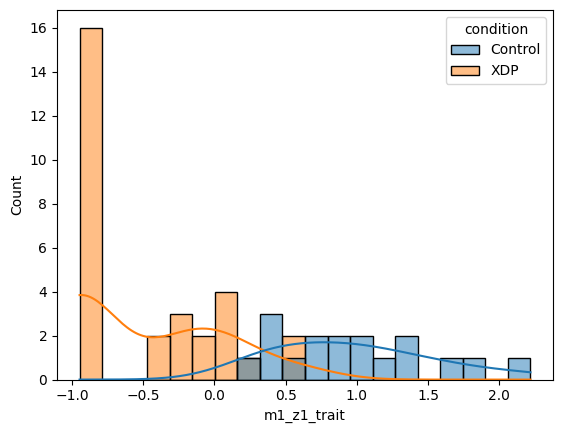

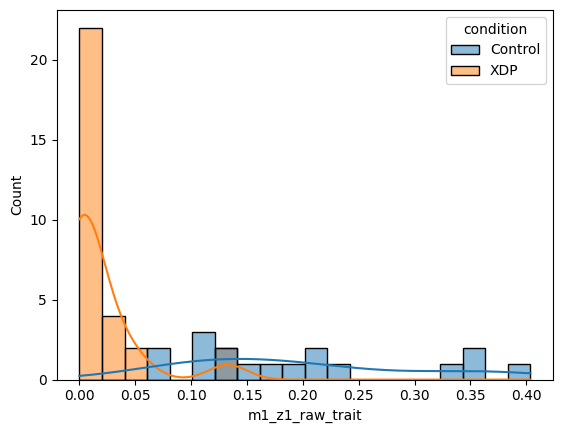

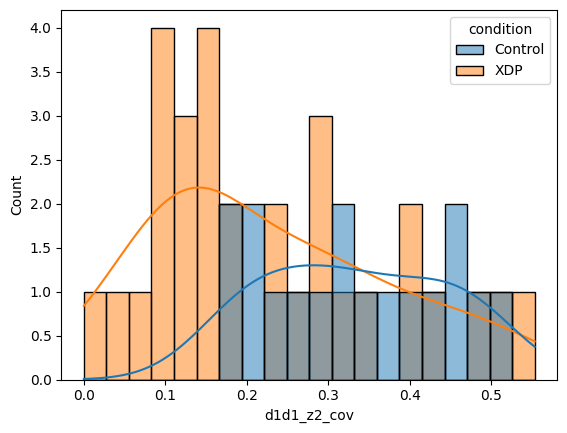

In [6]:
sns.histplot(data=df_meta, x="m1_z1_trait", bins=20, kde=True, hue="condition"); plt.show()
sns.histplot(data=df_meta, x="m1_z1_raw_trait", bins=20, kde=True, hue="condition"); plt.show()
sns.histplot(data=df_meta, x="d1d1_z2_cov", bins=20, kde=True, hue="condition"); plt.show()


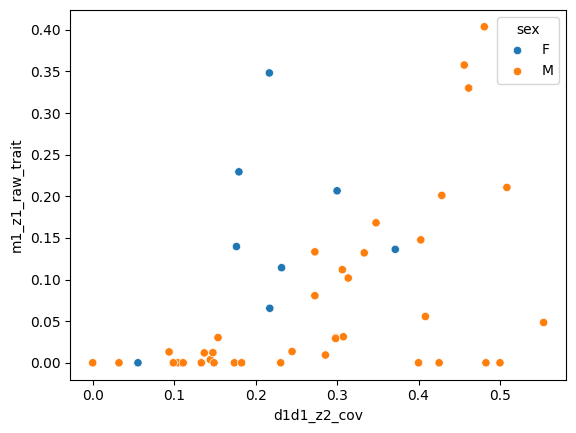

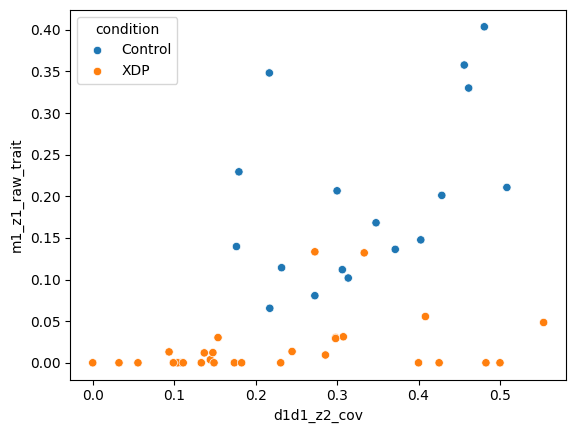

In [7]:
sns.scatterplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="sex"); plt.show()
sns.scatterplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="condition"); plt.show()


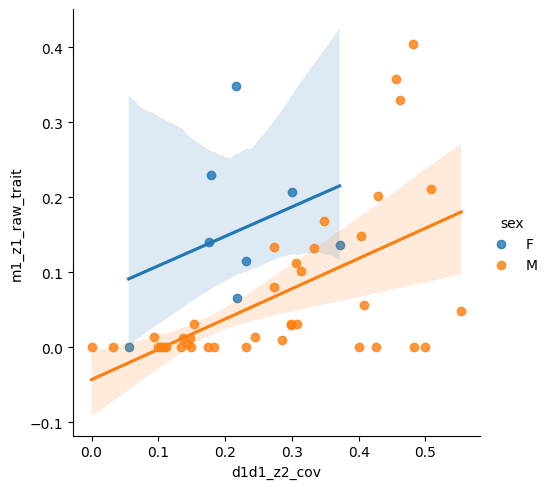

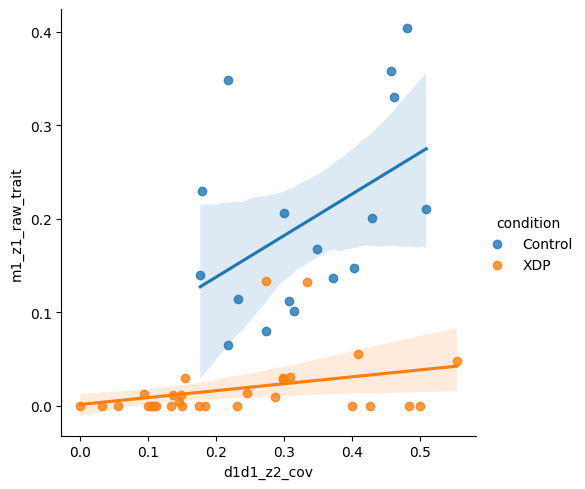

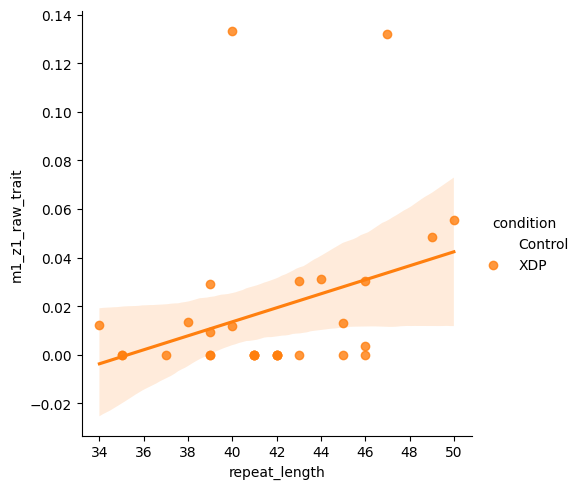

In [8]:
sns.lmplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="sex"); plt.show()
sns.lmplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="condition"); plt.show()
sns.lmplot(data=df_meta[df_meta["condition"] == "XDP"], x="repeat_length", y="m1_z1_raw_trait", hue="condition"); plt.show()


### Filer only Disesaed and Males for GWAS

In [9]:

import pandas as pd

df_meta_diseased = df_meta[
        (df_meta["condition"] == "XDP") &
        (df_meta["sex"] == "M")
        ].copy()

display(df_meta_diseased)

for var in ["age_of_onset", "age_of_death", "disease_duration", "repeat_length"]:
    numeric_var = pd.to_numeric(df_meta_diseased[var], errors="coerce")  # 'not_applicable' → NaN
    corr = df_meta_diseased["m1_z1_trait"].corr(numeric_var, method="spearman")
    print(f"Correlation between m1_z1_trait and {var}: {corr:.4f}")

donors_from_adata_nucseq_male_diseased = adata[
    (adata.obs["dataset"] == "nucseq") &
    (adata.obs["condition"] == "XDP") &
    (adata.obs["sex"] == "M")
].obs["original_donor_id"].unique().tolist()
print(donors_from_adata_nucseq_male_diseased)


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,41,56,15,615.0,Pnuemonia,SCF-18-004,0.000000,-0.946457,0.108108,41.0
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,51,54,3,114.0,Septicemia,SCF-20-025,0.013550,-0.106301,0.244755,369.0
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,30,43,13,598.0,Myocardial Infraction,SCF-21-030,0.030303,0.026528,0.298246,66.0
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,32,41,9,378.0,"Pnuemonia, Dystonia",SCF-18-003,0.000000,-0.946457,0.230769,164.0
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,38,41,3,132.0,Myocardial Infraction,SCF-20-023,0.031250,0.106301,0.307692,160.0
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,49,54,5,195.0,Pnuemonia,SCF-19-009,0.029197,-0.053075,0.298246,137.0
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,39,46,7,322.0,Probable Myocardial Infarction,SCF-20-024,0.003676,-0.380326,0.144444,272.0
SCF-22-043,SCF_22-043,M,XDP,C_1,6.83,0.82,4.0,B,NaN,SCF,...,46,52,6,240.0,Myocardial Infarction,SCF-22-043,0.011905,-0.268441,0.136986,84.0
SCF-19-018,SCF-19-018,M,XDP,C_1,6.78,0.78,4.0,B,6.0,SCF,...,33,40,7,315.0,Dystonia,SCF-19-018,0.000000,-0.946457,0.104167,179.0


Correlation between m1_z1_trait and age_of_onset: -0.0075
Correlation between m1_z1_trait and age_of_death: -0.0712
Correlation between m1_z1_trait and disease_duration: -0.3178
Correlation between m1_z1_trait and repeat_length: 0.3058
['SCF-20-025', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'SCF-18-004', 'SCF-20-023', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_029', 'SCF_21_032', 'SCF_21_041', 'SCF_21_034', 'SCF_22-048', 'SCF_20-026', 'SCF-22-045', 'SCF-22-044', 'SCF-19-020', 'SCF-22-042', 'SCF_22-052', 'SCF_23-083', 'SCF_22-060', 'SCF_23-080']


# GWAS on Diseased

chekc if there is an assoication beween trait and allele fo specific genes

GWS: gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/vcfs/xdp/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz

GSA: 

1) downlaod from Giulio Genovese Bucket:
```bash
for c in {1..22} X; do
  gcloud storage cp \
    "gs://bio-mocha/vcfs/nbb.mclean/impute/gsa.mclean_gsamd3.chr${c}.as.bcf" \
    "gs://bio-mocha/vcfs/nbb.mclean/impute/gsa.mclean_gsamd3.chr${c}.as.bcf.csi" \
    .
done
```
2) copy on bcuket
```bash
gsutil -m cp ./* gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/vcfs/xdp/genovese_gsa_imputed_raw_perchr/
```


trait ~ allele_dosage + PCs + sex + Age + d1d2_z2_cov

In [5]:
import subprocess

MOUNT = "/home/gdallagl/myworkdir/XDP/data/XDP/vcf"
NORM_VCF = "whole_xdp_norm/xdp_v3_impute_rename_plink.vcf.gz"

def bcftools(args):
    cmd = ["podman", "run", "--rm", "-w", "/data",
           "-v", f"{MOUNT}:/data", IMAGE_BCFTOOLS, "bcftools", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    return p.stdout, p.stderr, p.returncode

# 1) sample count
out, err, rc = bcftools(["query", "-l", NORM_VCF])
print("samples:", len(out.split()) if rc == 0 else f"ERROR: {err}")

# 2) site count
out, err, rc = bcftools(["index", "-n", NORM_VCF])
print("sites:", out.strip() if rc == 0 else f"ERROR: {err}")

# 3) INFO/FORMAT fields
out, err, rc = bcftools(["view", "-h", NORM_VCF])
if rc == 0:
    print("\n".join(l for l in out.splitlines() if l.startswith(("##INFO", "##FORMAT"))))
else:
    print("ERROR:", err)

samples: 15
sites: 4012449
##INFO=<ID=IMP,Number=0,Type=Flag,Description="Imputed marker">
##INFO=<ID=AF,Number=A,Type=Float,Description="ALT allele frequency computed from DS/GP field across target samples">
##INFO=<ID=AC,Number=A,Type=Integer,Description="ALT allele count from GT across target samples">
##INFO=<ID=AN,Number=A,Type=Integer,Description="Total number of alleles in called genotypes">
##INFO=<ID=INFO,Number=A,Type=Float,Description="IMPUTE info quality score">
##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">


In [4]:
VCF_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/vcf"
MOUNT = VCF_FOLDER


RAW_VCF  = "whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz"   
RAW_TBI  = "whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz.tbi"

NORM_VCF =  "whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz"   
NORM_TBI =  "whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz.tbi"   

GENES_BED = ["MSH3", "PMS2"]# "PDE8B"]
BED = "subset/genes.bed"
GENOME = "GRCh38"
FLANK = 20000 # ±20 kb around each gene (regulatory + nearby modifier variants)

N_THREADS = 16  # bump from 4: bcftools/plink2 both support multithreading and the host has far more cores available

# Format toggle for the candidate-region pipeline: switches bcftools/plink2 between text VCF and binary BCF.
# BCF skips text encode/decode (faster read/write); this is the single place controlling it so the
# -O flag, index type, and plink2 input flag can never drift out of sync with each other.
TYPE = "bcf"  # "vcf" or "bcf"
EXT              = {"vcf": "vcf.gz", "bcf": "bcf"}[TYPE]
IDX_EXT          = {"vcf": "tbi", "bcf": "csi"}[TYPE]        # tabix (.tbi) only applies to bgzipped text VCF; BCF needs CSI
BCFTOOLS_OFLAG   = {"vcf": "-Oz", "bcf": "-Ob"}[TYPE]        # output format for bcftools view/norm/annotate
BCFTOOLS_IDXFLAG = {"vcf": "-t", "bcf": ""}[TYPE]            # -t forces TBI (VCF-only); omit for BCF -> bcftools index defaults to CSI
PLINK_INFLAG     = {"vcf": "--vcf", "bcf": "--bcf"}[TYPE]    # plink2 flag matching the input format

# bith by gene and samples
SUBSET_VCF = f"subset/candidate.{EXT}"

SUBSET_NORM_VCF = f"subset/candidate.norm.{EXT}"
SUBSET_NORM_IDX = f"subset/candidate.norm.{EXT}.{IDX_EXT}"

SUBSET_PGEN = "subset/plink/candidate"
SUBSET_PGEN_NORM = "subset/plink/candidate_norm"


PCA = "whole_xdp_PCA"
SUBSET_FOR_NORM_PCA = "subset/for_PCA/vcf_pca.norm.vcf.gz"
SUBSET_PGEN_PCA = "subset/for_PCA/vcf_pca"
SUBSET_PGEN_PCA_QC = "subset/for_PCA/vcf_pca_qc"
SUBSET_PCs = "subset/for_PCA/PCA"
N_PCs = 10

MOUNT = VCF_FOLDER
IMAGE_BCFTOOLS = "quay.io/biocontainers/bcftools:1.21--h8b25389_0"
IMAGE_PLINK = "quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0"


In [11]:
# Chekc how the chr stirng are formatted --< same must be in .bed file
cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools view -h {NORM_VCF}'
print(cmd)
!{cmd} | grep "^##contig" | head

# ATTENTION:  GRCh38  == assembly=38

podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/XDP/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools view -h whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz
##contig=<ID=1,length=248956422>
##contig=<ID=2,length=242193529>
##contig=<ID=3,length=198295559>
##contig=<ID=4,length=190214555>
##contig=<ID=5,length=181538259>
##contig=<ID=6,length=170805979>
##contig=<ID=7,length=159345973>
##contig=<ID=8,length=145138636>
##contig=<ID=9,length=138394717>
##contig=<ID=10,length=133797422>


In [12]:
# ── Step 1: Build BED file for candidate genes ────────────────────────────────
# A BED file defines genomic windows to extract from the VCF.
# Each row = one region: chrom  start(0-based)  end(1-based)  name
# We add ±FLANK bp around each gene to capture regulatory and nearby variants.

import requests, os, pandas as pd

def gene_coords(symbol, build="GRCh38"):
    """Query the Ensembl REST API for a gene's genomic coordinates."""
    server = ("https://rest.ensembl.org" if build == "GRCh38"
              else "https://grch37.rest.ensembl.org")
    r = requests.get(
        f"{server}/lookup/symbol/homo_sapiens/{symbol}",
        headers={"Content-Type": "application/json"}
    )
    r.raise_for_status()
    d = r.json()
    return d["seq_region_name"], d["start"], d["end"], d["assembly_name"]

rows = []
for g in GENES_BED:                               # GENES_BED = ["MSH3", "PMS2"]
    chrom, start, end, asm = gene_coords(g, GENOME)
    # Sanity check: ensure the API returned the expected genome build
    assert asm.startswith(GENOME), f"{g}: API returned {asm}, expected {GENOME}"
    # BED is 0-based half-open; Ensembl uses 1-based closed → subtract 1 from start
    rows.append({
        "gene":  g,
        "chrom": "" + chrom, # ATTENTION :cejkc hwo cbf is formtted
        "start": max(0, start - 1 - FLANK),   # upstream flank, clamped to 0
        "end":   end + FLANK,                  # downstream flank
    })

df_bed = (pd.DataFrame(rows)
            .sort_values(["chrom", "start"])
            .reset_index(drop=True))

# Write BED file: tab-separated, no header (bcftools -R expects this format)
os.makedirs(f"{VCF_FOLDER}/subset", exist_ok=True)
df_bed[["chrom", "start", "end", "gene"]].to_csv(
    f"{VCF_FOLDER}/{BED}", sep="\t", header=False, index=False
)
print(f"BED file written → {VCF_FOLDER}/{BED}")
df_bed   # show gene windows

BED file written → /home/gdallagl/myworkdir/XDP/data/XDP/vcf/subset/genes.bed


,gene,chrom,start,end
0,MSH3,5,80634612,80900295
1,PMS2,7,5950924,6029130


In [13]:
# ── Step 2: Find donors present in both snRNA-seq and the VCF ────────────────

# donro in vcf
samples_in_vcf = !podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools query -l {NORM_VCF}   

print(f"Donors from adata nucseq {len(donors_from_adata_nucseq)}: {donors_from_adata_nucseq}")
print(f"Donors from adata nucseq male diseased {len(donors_from_adata_nucseq_male_diseased)}: {donors_from_adata_nucseq_male_diseased}")
print(f"Samples in VCF {len(samples_in_vcf)}: {samples_in_vcf}")

# Exact-match intersection: only donors whose IDs are identical in both files
samples_intersection = sorted(set(donors_from_adata_nucseq_male_diseased) & set(samples_in_vcf))
print(f"Exact-match intersection:           {len(samples_intersection)}")
print("\nMatched donors:"); print(samples_intersection)

# Check for donors in adata but NOT in VCF (possible ID format issue)
not_present_in_adata = set(samples_in_vcf) - set(donors_from_adata_nucseq_male_diseased)
if not_present_in_adata:
    print(f"\nDonors in VCF but NOT in adata_male_diseased ({len(not_present_in_adata)}): {sorted(not_present_in_adata)}")
    print("→ Check for suffix/underscore differences in VCF sample names above")

Donors from adata nucseq 47: ['SCF-20-025', 'SCF-22-054CM', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'PCMC-16-011', 'SCF-22-058CF', 'SCF-18-004', 'SCF-20-023', 'SCF_21-037CM2', 'SCF-23-068CM', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_029', 'SCF_21_032', 'SCF_22_049CCF', 'SCF_22_063CM', 'SCF_23_074CF', 'SCF_21_041', 'SCF_21_034', 'SCF_22_067CM', 'SCF_23_079CF', 'SCF_22_065CM', 'SCF_23_075CM', 'SCF_23_072CF', 'SCF_22-050CM6', 'SCF_22-048', 'SCF_20-026', 'SCF_22-046CF', 'SCF_22-057CM', 'SCF_22-056CF', 'SCF-22-045', 'SCF_23-081CM', 'SCF-22-044', 'SCF-19-020', 'SCF-22-042', 'SCF_22-052', 'SCF_23-083', 'SCF_22-060', 'SCF_23-080']
Donors from adata nucseq male diseased 29: ['SCF-20-025', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'SCF-18-004', 'SCF-20-023', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_02

In [14]:
# 3a. Extract only the genomic windows defined in the BED file and only the donors present in the intersection.
cmd_sub = (
    f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} '
    f'bcftools view '
    f'-R {BED} '                             # restrict to gene windows
    f'-s {",".join(samples_intersection)} '  # restrict to our donors
    f'--threads {N_THREADS} '
    f'{NORM_VCF} '                           # input (normalized whole-cohort VCF)
    f'{BCFTOOLS_OFLAG} -o {SUBSET_VCF}'
)
print("3a. Subsetting VCF:"); print(cmd_sub)
!{cmd_sub}


3a. Subsetting VCF:
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/XDP/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools view -R subset/genes.bed -s PCMC-16-012,SCF-18-003,SCF-18-004,SCF-18-006,SCF-19-009,SCF-19-014,SCF-19-018,SCF-20-023,SCF-20-025,SCF-21-030,SCF-22-045,SCF_20-024,SCF_22-043 --threads 16 whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz -Ob -o subset/candidate.bcf


In [15]:
# ── Step 3a.5: Rename chromosomes Ensembl→UCSC so they match the FASTA ───────
# VCF contigs are named "5","7" etc.; the reference FASTA uses "chr5","chr7"
# bcftools norm -f will fail unless the naming matches.

SUBSET_VCF_UCSC = f"subset/candidate.ucsc.{EXT}"

chrom_map_path = f"{VCF_FOLDER}/subset/chrom_rename.txt"
with open(chrom_map_path, "w") as fh:
    for c in [*range(1, 23), "X", "Y", "MT"]:
        fh.write(f"{c}\tchr{c}\n")

cmd_rename = (
    f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} "
    f"bcftools annotate --rename-chrs subset/chrom_rename.txt "
    f"--threads {N_THREADS} "
    f"{SUBSET_VCF} {BCFTOOLS_OFLAG} -o {SUBSET_VCF_UCSC}"
)
print("3a.5. Renaming chromosomes:"); print(cmd_rename)
!{cmd_rename}

cmd_idx_ucsc = (
    f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} "
    f"bcftools index {BCFTOOLS_IDXFLAG} -f {SUBSET_VCF_UCSC}"
)
!{cmd_idx_ucsc}


3a.5. Renaming chromosomes:
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/XDP/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools annotate --rename-chrs subset/chrom_rename.txt --threads 16 subset/candidate.bcf -Ob -o subset/candidate.ucsc.bcf


In [16]:
# 3b. Re-normalise the subsetted VCF
FASTA = "fasta_genome/GRCh38.fasta"
cmd_norm = (
    f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} '
    f'bcftools norm '
    f'-f {FASTA} '       # left-align + use reference for complex indels
    f'-m -any '          # split multi-allelic records
    f'--threads {N_THREADS} '
    f'{SUBSET_VCF_UCSC} {BCFTOOLS_OFLAG} -o {SUBSET_NORM_VCF}'
)
print("\n3b. Normalising:"); print(cmd_norm)
!{cmd_norm}

# 3c. Index the normalised subset
cmd_idx = (
    f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} '
    f'bcftools index {BCFTOOLS_IDXFLAG} -f {SUBSET_NORM_VCF}'
)
print("\n3c. Indexing:"); print(cmd_idx)
!{cmd_idx}



3b. Normalising:
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/XDP/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools norm -f fasta_genome/GRCh38.fasta -m -any --threads 16 subset/candidate.ucsc.bcf -Ob -o subset/candidate.norm.bcf


Lines   total/split/joined/realigned/removed/skipped:	234/0/0/0/0/0

3c. Indexing:
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/XDP/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools index  -f subset/candidate.norm.bcf


In [17]:
# ── Step 4: Convert normalized subset VCF → PLINK2 format, then apply QC ─────

# 4a. Convert VCF/BCF to plink2 binary (.pgen / .pvar / .psam)

os.makedirs(f"{VCF_FOLDER}/{SUBSET_PGEN.rsplit('/', 1)[0]}", exist_ok=True)

cmd = (f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
  f"plink2 {PLINK_INFLAG} {SUBSET_NORM_VCF} "
  f"--set-all-var-ids '@:#:$r:$a' "  #assign a deterministic ID to every
  f"--new-id-max-allele-len 100 missing " #alleles longer than 100 bp get the token "missing" in their ID --> avoids IDs that are thousands of chars long
  f"--make-pgen "
  f"--out {SUBSET_PGEN} --threads {N_THREADS}"
)
print("Converting to plink:", cmd)
!{cmd}

# 4b. Quality-control the plink file
cmd_qc = (f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
  f"  plink2 --pfile {SUBSET_PGEN} "
  f"  --geno 0.05 " #remove variants missing in >5% of samples (unreliable calls)
  f"  --mind 0.1 " #remove samples missing >10% of variants (poor sequencing)
  f"  --maf 0.05 " #keep only common variants (MAF ≥ 5%)
  f"  --make-pgen --out {SUBSET_PGEN}_qc --threads {N_THREADS}")
print("\nQC:", cmd_qc)
!{cmd_qc}


Converting to plink: podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/XDP/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0 plink2 --bcf subset/candidate.norm.bcf --set-all-var-ids '@:#:$r:$a' --new-id-max-allele-len 100 missing --make-pgen --out subset/plink/candidate --threads 16


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to subset/plink/candidate.log.
Options in effect:
  --bcf subset/candidate.norm.bcf
  --make-pgen
  --new-id-max-allele-len 100 missing
  --out subset/plink/candidate
  --set-all-var-ids @:#:$r:$a
  --threads 16

Start time: Mon Jul 13 17:21:36 2026
314189 MiB RAM detected, ~90479 available; reserving 90415 MiB for main
workspace.
Using up to 16 threads (change this with --threads).
--bcf: 234 variants scanned.
--bcf: subset/plink/candidate-temporary.pgen +
subset/plink/candidate-temporary.pvar.zst +
subset/plink/candidate-temporary.psam written.
13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from
subset/plink/candidate-temporary.psam.
234 variants loaded from subset/plink/candidate-temporary.pvar.zst.
Note: No phenotype data present.
Writing subset/plink/candidate.psam ... done.
Writing subset/plink/can

### Ancestry PCA (full XDP cohort)

PCA is computed on **all donors in the XDP WGS VCF** (not just those with
snRNA-seq data) to get stable ancestry estimates. PC1–PC3 are then used as
covariates in the GWAS to correct for population structure.

Pipeline:
1. Convert full VCF → plink2 (autosomes only)
2. QC: MAF ≥ 5 %, geno ≤ 5 %
3. Exclude known long-range LD regions + LD-prune to independent SNPs
4. Compute 10 PCs

In [18]:
# ── Step 5a–b: Define PCA paths; convert full XDP VCF to plink; QC ───────────
# PCA is computed on the FULL XDP WGS cohort (all donors in the VCF),
# not just those with phenotype data. This gives more stable PC estimates.

PCA_FOLDER      = "whole_xdp_PCA"                  # all PCA output goes here
PCA_PGEN        = f"{PCA_FOLDER}/vcf_pca"          # pgen from all autosome variants
PCA_PGEN_QC     = f"{PCA_FOLDER}/vcf_pca_qc"      # pgen after MAF + geno filters
PCA_PGEN_PRUNED = f"{PCA_FOLDER}/vcf_pca_pruned"  # prefix for prune.in / prune.out
PCA_OUT         = f"{PCA_FOLDER}/PCA"              # final PCA output prefix
N_PCs           = 10                                # number of PCs to compute

os.makedirs(f"{VCF_FOLDER}/{PCA_FOLDER}", exist_ok=True)

# 5a. Convert full normalized XDP VCF → plink2 binary format (all donors)
print("Step 5a: Converting full XDP VCF to plink...")
cmd = (f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
    f"plink2 --vcf {NORM_VCF} "
    f"--autosome " #exclude chrX, chrY, chrM; sex/MT chromosomes distort PCA
    f"--set-all-var-ids '@:#:$r:$a' " # chr:pos:ref:alt as variant ID
    f"--new-id-max-allele-len 100 missing " # very long alleles get ID "missing"
    f"--make-pgen --out {PCA_PGEN} --threads {N_THREADS}")
print(cmd); 
!{cmd}

# 5b. QC: remove low-frequency variants and high-missingness variants
print("\nStep 5b: QC for PCA...")
cmd_qc = (f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
    f"plink2 --pfile {PCA_PGEN} "
    f"--geno 0.05 " #drop variants missing in >5% of samples
    f"--maf 0.05 " #drop variants with minor allele frequency < 5%
    f"--make-pgen --out {PCA_PGEN_QC} --threads {N_THREADS}")
print(cmd_qc); 
!{cmd_qc}


Step 5a: Converting full XDP VCF to plink...
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/XDP/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0 plink2 --vcf whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz --autosome --set-all-var-ids '@:#:$r:$a' --new-id-max-allele-len 100 missing --make-pgen --out whole_xdp_PCA/vcf_pca --threads 16
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to whole_xdp_PCA/vcf_pca.log.
Options in effect:
  --autosome
  --make-pgen
  --new-id-max-allele-len 100 missing
  --out whole_xdp_PCA/vcf_pca
  --set-all-var-ids @:#:$r:$a
  --threads 16
  --vcf whole_xdp_norm/McCarroll_Macosko_XDP_WGS_20240501.donors_renamed_filtered_norm_cleaned.vcf.gz

Start time: Mon Jul 13 17:21:38 2026
314189 MiB RAM detected, ~90466 available; reserving 90402 MiB for main
workspace.
Using up to 

In [19]:
# From: https://raw.githubusercontent.com/meyer-lab-cshl/plinkQC/master/inst/extdata/high-LD-regions-hg38-GRCh38.txt
long_range_ld = """chr1 47761740 51761740 LRLD1
chr1 47761740 51761740 1
chr2 85919365 100517106 2
chr2 89917298 89917322 3
chr2 87416141 87416186 4
chr2 87417804 87417863 5
chr2 87418924 87418981 6
chr1 144106678 144106709 7
chr14 87391719 87391996 8
chr9 40365644 40365693 9
chr2 182427027 189427029 10
chr3 47483505 49987563 11
chr3 83368158 86868160 12
chr5 44464140 51168409 13
chr5 129636407 132636409 14
chr6 25391792 33424245 15
chr6 26726947 26726981 16
chr6 57788603 58453888 17
chr6 61109122 61357029 18
chr6 61424410 61424451 19
chr9 64198500 64200392 20
chr6 139637169 142137170 21
chr7 54964812 66897578 22
chr7 62182500 62277073 23
chr12 34639034 34639084 24
chr14 94658026 94658080 25
chr17 43159541 43159574 26
chr2 135275091 135275210 27
chr1 181955019 181955047 28
chr22 30060084 30060162 29
chr9 88958735 88959017 30
chr2 207609786 207609808 31
chr22 42980497 42980522 32
chr20 4031884 4032441 33
chr8 8105067 12105082 34
chr8 43025699 48924888 35
chr8 47303500 47317337 36
chr8 110918594 113918595 37
chr10 36671065 43184546 38
chr10 41693521 41885273 39
chr1 125169943 125170022 40
chr11 88127183 91127184 41
chr12 32955798 41319931 42
chr20 33948532 36438183 43
"""
LRLD_FILE = "fasta_genome/long_range_ld_GRCh38.txt"
with open(f"{VCF_FOLDER}/{LRLD_FILE}", "w") as f:
    f.write(long_range_ld)


In [20]:
# ── Step 5c–d: LD-prune variants, then compute ancestry PCA ──────────────────

# 5c. LD pruning → produces {PCA_PGEN_PRUNED}.prune.in (the independent variant list)
print("Step 5c: LD pruning...")
cmd_prune = (
    f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
    f"plink2 --pfile {PCA_PGEN_QC} "
    f"--maf 0.05 --geno 0.02 "
    f"--hwe 1e-6 " #remove variants deviating from Hardy-Weinberg equilibrium
    f"--snps-only " # keep only biallelic SNPs before running any other filter 
    f"--rm-dup exclude-all "  #drop any variants sharing the same ID string  (long alleles all get ID "missing")
    f"--bad-ld " # "yes, I know N < 50, proceed anyway."
    f"--exclude range {LRLD_FILE} " #remove the long-range LD blocks written above
    f"--indep-pairwise 200 50 0.2 " #sliding-window pruning: window = 200 variants, step = 50, max r² = 0.2 between any pair
    f"--out {PCA_PGEN_PRUNED}")
print(cmd_prune); 
!{cmd_prune}

# 5d-i. Pre-compute allele frequencies (required because N=31 < 50 threshold)
print("\nStep 5d-i: Computing allele frequencies...")
cmd_freq = (
    f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
    f"plink2 --pfile {PCA_PGEN_QC} "
    f"--extract {PCA_PGEN_PRUNED}.prune.in "
    f"--freq " # --freq writes {PCA_OUT}.afreq, which we pass to --pca via --read-freq
    f"--out {PCA_OUT}")
print(cmd_freq); 
!{cmd_freq}

# 5d-ii. Compute PCA using the pre-computed frequencies
#   --read-freq {PCA_OUT}.afreq → supply allele freqs directly (bypasses N<50 guard)
#   --pca {N_PCs}               → compute top N eigenvectors
print("\nStep 5d-ii: Computing PCA...")
cmd_pca = (
    f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
    f"plink2 --pfile {PCA_PGEN_QC} "
    f"--extract {PCA_PGEN_PRUNED}.prune.in "
    f"--maf 0.05 --geno 0.02 --hwe 1e-6 "
    f"--read-freq {PCA_OUT}.afreq "
    f"--pca {N_PCs} "
    f"--out {PCA_OUT}")
print(cmd_pca); 
!{cmd_pca}


Step 5c: LD pruning...
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/XDP/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0 plink2 --pfile whole_xdp_PCA/vcf_pca_qc --maf 0.05 --geno 0.02 --hwe 1e-6 --snps-only --rm-dup exclude-all --bad-ld --exclude range fasta_genome/long_range_ld_GRCh38.txt --indep-pairwise 200 50 0.2 --out whole_xdp_PCA/vcf_pca_pruned
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to whole_xdp_PCA/vcf_pca_pruned.log.
Options in effect:
  --bad-ld
  --exclude range fasta_genome/long_range_ld_GRCh38.txt
  --geno 0.02
  --hwe 1e-6
  --indep-pairwise 200 50 0.2
  --maf 0.05
  --out whole_xdp_PCA/vcf_pca_pruned
  --pfile whole_xdp_PCA/vcf_pca_qc
  --rm-dup exclude-all
  --snps-only

Start time: Mon Jul 13 17:21:48 2026
314189 MiB RAM detected, ~90479 available; reserving 90415 MiB for main
workspace.
Using up to 48 threads (cha

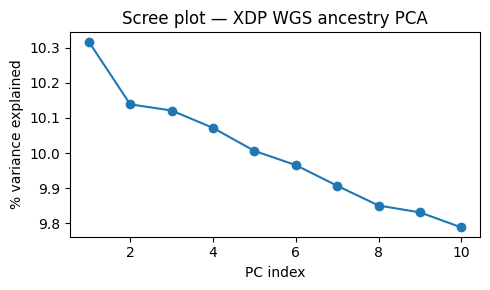

PC scores (first 5 donors):


,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,PCMC-16-011,0.145423,-0.117074,0.220676,0.033199,0.082611,0.194314,0.086305,-0.002521,0.230084,-0.221438
1,PCMC-16-012,0.151813,-0.144165,0.161088,0.064444,-0.014435,0.067784,-0.065121,0.206288,0.068751,-0.099444
2,PCMC_17-005,0.078685,0.002348,0.151297,-0.005681,0.141958,0.126402,-0.420942,0.042715,-0.149866,-0.114692
3,PCMC_17-010,0.007593,-0.044759,-0.291861,0.037569,-0.201474,0.048006,0.246662,-0.051078,-0.146609,0.041620
4,PCMC_17-012,0.042215,-0.052705,0.072862,0.522853,0.054095,0.144296,0.062331,0.212627,0.323961,0.240715



Variance explained:


,eigenval,PC,pct
0,1.06059,PC1,10.317023
1,1.04227,PC2,10.138813
2,1.04046,PC3,10.121206
3,1.03538,PC4,10.071790
4,1.02866,PC5,10.006420
5,1.02450,PC6,9.965953
6,1.01847,PC7,9.907296
7,1.01269,PC8,9.851070
8,1.01069,PC9,9.831615
9,1.00629,PC10,9.788813


In [21]:
# ── Step 5e: Load PCA results into Python ────────────────────────────────────
# plink2 writes a header starting with "#FID" → strip the "#" to get clean column names.
# eigenvec: one row per donor, columns FID  IID  PC1 ... PC10
# eigenval: one eigenvalue per PC (proportional to variance explained)

pcs = pd.read_csv(f"{VCF_FOLDER}/{PCA_OUT}.eigenvec", sep=r"\s+")
pcs.columns = [c.lstrip("#") for c in pcs.columns]  # "#FID" → "FID"

eigenvals = pd.read_csv(f"{VCF_FOLDER}/{PCA_OUT}.eigenval", header=None, names=["eigenval"])
eigenvals["PC"]  = [f"PC{i+1}" for i in range(len(eigenvals))]
eigenvals["pct"] = eigenvals["eigenval"] / eigenvals["eigenval"].sum() * 100

# Scree plot: shows how much ancestry signal each PC captures.
# A steep elbow indicates the first few PCs explain most genetic structure.
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(range(1, len(eigenvals)+1), eigenvals["pct"], marker="o")
ax.set_xlabel("PC index"); ax.set_ylabel("% variance explained")
ax.set_title("Scree plot — XDP WGS ancestry PCA")
plt.tight_layout(); plt.show()

print("PC scores (first 5 donors):"); display(pcs.head())
print("\nVariance explained:"); display(eigenvals)

In [22]:
"""
 All 31 donors are almost certainly from the same ethnic background — there is no population structure to detect. 

 ncluding PC1–PC3 as covariates adds random noise to the model, not ancestry correction
"""

'\n All 31 donors are almost certainly from the same ethnic background — there is no population structure to detect. \n\n ncluding PC1–PC3 as covariates adds random noise to the model, not ancestry correction\n'

### Kinship remvoal

In [23]:
# Compute KING kinship from pruned variants
cmd_king = f"""
    podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \\
    plink2 --pfile {PCA_PGEN_QC} \\
    --extract {PCA_PGEN_PRUNED}.prune.in \\
    --make-king-table \\
    --king-table-filter 0.0442 \\
    --out {PCA_FOLDER}/kinship"""
# --king-table-filter 0.0442 → only print pairs with kinship > 2nd cousin threshold
!{cmd_king}

# Load pairs and greedily remove one from each
import pandas as pd, networkx as nx
king = pd.read_csv(f"{VCF_FOLDER}/{PCA_FOLDER}/kinship.kin0", sep="\t")
king.columns = [c.lstrip("#") for c in king.columns]  # "#FID1" → "FID1"# Build graph: each node = sample, each edge = related pair
display(king)
G = nx.Graph()
for _, row in king.iterrows():
    G.add_edge(row["IID1"], row["IID2"])  # was row["#ID1"] — wrong
# Greedy: remove the node with most connections first
to_remove = set()
while G.number_of_edges() > 0:
    worst = max(G.nodes, key=lambda n: G.degree(n))
    to_remove.add(worst)
    G.remove_node(worst)
print(f"Samples to exclude: {to_remove}")

# # Filter df_gwas to exclude related samples
# df_gwas = df_gwas[~df_gwas.index.isin(to_remove)]
# print(f"GWAS N after kinship pruning: {len(df_gwas)}")


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to whole_xdp_PCA/kinship.log.
Options in effect:
  --extract whole_xdp_PCA/vcf_pca_pruned.prune.in
  --king-table-filter 0.0442
  --make-king-table
  --out whole_xdp_PCA/kinship
  --pfile whole_xdp_PCA/vcf_pca_qc

Start time: Mon Jul 13 17:21:54 2026
314189 MiB RAM detected, ~90469 available; reserving 90405 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
31 samples (0 females, 0 males, 31 ambiguous; 31 founders) loaded from
whole_xdp_PCA/vcf_pca_qc.psam.
1936929 variants loaded from whole_xdp_PCA/vcf_pca_qc.pvar.
Note: No phenotype data present.
--extract: 37816 variants remaining.
37816 variants remaining after main filters.
--make-king-table pass 1/1: Scanning for rare variants... 101316192325283134374043464952565962666973768084899397done.
0 variants handled by initial scan (37816 remaining)

,IID1,IID2,NSNP,HETHET,IBS0,KINSHIP
0,SCF-21-030,SCF-20-023,37816,0.267083,0.103184,0.057098


Samples to exclude: {'SCF-21-030'}


### Prepare GWAS Input Files

Merge the snRNA-seq trait, clinical covariates, and ancestry PCs, then write
two plain-text files that plink2 expects:

- **pheno.txt** — `IID  m1_z1_trait` (rank-normalised)
- **covar.txt** — `IID  d1d1_z2_cov  age  sex_num  PC1  PC2  PC3`

In [24]:
# ── Step 6: Assemble per-donor GWAS table and write plink input files ─────────

# Start from the XDP-only subset of df_meta (computed in the correlations cell above)
df_gwas = df_meta_diseased.copy()

# Encode sex as integer: plink2 convention = 1 male, 2 female
# "ambiguous" (unknown) is left as NaN and those donors will be dropped below.
sex_map = {"M": 1, "male": 1, "F": 2, "female": 2}
df_gwas["sex_num"] = df_gwas["sex"].map(sex_map)

# age_of_death is the only age variable always defined for all donors.
# age_of_onset is 'not_applicable' for controls → not useful here.
# pd.to_numeric(..., errors="coerce") converts any remaining strings to NaN.
df_gwas["age"] = pd.to_numeric(df_gwas["age_of_death"], errors="coerce")

# Merge ancestry PCs: IID in pcs matches donor_id in df_gwas (both are index).
# We only bring in the first 3 PCs as covariates (diminishing returns beyond PC3).
df_gwas = df_gwas.merge(
    pcs.set_index("IID")[["PC1", "PC2", "PC3"]],
    left_on="original_donor_id",   # ← was left_index=True
    right_index=True,
    how="left"
)

display(df_gwas)


# Drop any donor missing the trait, PCs, age, sex, or the cell-type covariate.
# These donors cannot be included in the regression.
df_gwas = df_gwas.dropna(
    subset=["m1_z1_trait", "d1d1_z2_cov", "age", "sex_num", "PC1"]
)

display(df_gwas)

# IID column must match VCF sample names exactly for plink to link files.
df_gwas["IID"] = df_gwas["original_donor_id"]  # must match VCF sample names in pgen .psam

print(f"Final GWAS N = {len(df_gwas)} donors")
display(df_gwas[["IID","m1_z1_trait","d1d1_z2_cov","age","sex_num","PC1","PC2","PC3"]])

# ── Write phenotype file ──────────────────────────────────────────────────────
# Two-column TSV: IID  m1_z1_trait
# na_rep="NA" ensures plink recognises missing values correctly.
TRAIT     = "m1_z1_trait"
COVS      = ["d1d1_z2_cov", "age"] # "sex_num"] # "PC1", "PC2", "PC3"]
PHENO_FILE   = "subset/gwas_input_covs/pheno.txt"
COVAR_FILE   = "subset/gwas_input_covs/covar.txt"
RESULTS_FILE = "subset/results/results"

os.makedirs(f"{VCF_FOLDER}/subset/gwas_input_covs", exist_ok=True)
os.makedirs(f"{VCF_FOLDER}/subset/results",         exist_ok=True)

pheno = df_gwas[["IID", TRAIT]]
pheno.to_csv(f"{VCF_FOLDER}/{PHENO_FILE}", sep="\t", index=False, na_rep="NA")
print(f"\nPhenotype file written → {PHENO_FILE}  ({len(pheno)} rows)")

# ── Write covariate file ──────────────────────────────────────────────────────
# Columns: IID + all covariates listed in COVS.
# plink reads this and --covar-name selects which columns to actually use.
covar = df_gwas[["IID"] + COVS]
covar.to_csv(f"{VCF_FOLDER}/{COVAR_FILE}", sep="\t", index=False, na_rep="NA")
print(f"Covariate file written  → {COVAR_FILE}  (covariates: {COVS})")

,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total,sex_num,age,PC1,PC2,PC3
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,SCF-18-004,0.000000,-0.946457,0.108108,41.0,1,56,-0.054080,0.217810,0.219315
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,SCF-20-025,0.013550,-0.106301,0.244755,369.0,1,54,0.038035,-0.576789,-0.109981
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,SCF-21-030,0.030303,0.026528,0.298246,66.0,1,43,-0.524913,0.037219,0.159795
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,SCF-18-003,0.000000,-0.946457,0.230769,164.0,1,41,0.077991,0.208763,-0.155861
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,SCF-20-023,0.031250,0.106301,0.307692,160.0,1,41,-0.610642,-0.087810,0.019443
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,SCF-19-009,0.029197,-0.053075,0.298246,137.0,1,54,0.052972,-0.145604,0.134704
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,SCF-20-024,0.003676,-0.380326,0.144444,272.0,1,46,-0.121999,0.022155,0.061453
SCF-22-043,SCF_22-043,M,XDP,C_1,6.83,0.82,4.0,B,NaN,SCF,...,SCF-22-043,0.011905,-0.268441,0.136986,84.0,1,52,0.125397,-0.064838,0.309777
SCF-19-018,SCF-19-018,M,XDP,C_1,6.78,0.78,4.0,B,6.0,SCF,...,SCF-19-018,0.000000,-0.946457,0.104167,179.0,1,40,-0.002132,0.203320,0.131776


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total,sex_num,age,PC1,PC2,PC3
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,SCF-18-004,0.000000,-0.946457,0.108108,41.0,1,56,-0.054080,0.217810,0.219315
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,SCF-20-025,0.013550,-0.106301,0.244755,369.0,1,54,0.038035,-0.576789,-0.109981
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,SCF-21-030,0.030303,0.026528,0.298246,66.0,1,43,-0.524913,0.037219,0.159795
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,SCF-18-003,0.000000,-0.946457,0.230769,164.0,1,41,0.077991,0.208763,-0.155861
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,SCF-20-023,0.031250,0.106301,0.307692,160.0,1,41,-0.610642,-0.087810,0.019443
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,SCF-19-009,0.029197,-0.053075,0.298246,137.0,1,54,0.052972,-0.145604,0.134704
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,SCF-20-024,0.003676,-0.380326,0.144444,272.0,1,46,-0.121999,0.022155,0.061453
SCF-22-043,SCF_22-043,M,XDP,C_1,6.83,0.82,4.0,B,NaN,SCF,...,SCF-22-043,0.011905,-0.268441,0.136986,84.0,1,52,0.125397,-0.064838,0.309777
SCF-19-018,SCF-19-018,M,XDP,C_1,6.78,0.78,4.0,B,6.0,SCF,...,SCF-19-018,0.000000,-0.946457,0.104167,179.0,1,40,-0.002132,0.203320,0.131776


Final GWAS N = 13 donors


,IID,m1_z1_trait,d1d1_z2_cov,age,sex_num,PC1,PC2,PC3
donor_id,,,,,,,,
SCF-18-004,SCF-18-004,-0.946457,0.108108,56,1,-0.054080,0.217810,0.219315
SCF-20-025,SCF-20-025,-0.106301,0.244755,54,1,0.038035,-0.576789,-0.109981
SCF-21-030,SCF-21-030,0.026528,0.298246,43,1,-0.524913,0.037219,0.159795
SCF-18-003,SCF-18-003,-0.946457,0.230769,41,1,0.077991,0.208763,-0.155861
SCF-20-023,SCF-20-023,0.106301,0.307692,41,1,-0.610642,-0.087810,0.019443
SCF-19-009,SCF-19-009,-0.053075,0.298246,54,1,0.052972,-0.145604,0.134704
SCF-20-024,SCF_20-024,-0.380326,0.144444,46,1,-0.121999,0.022155,0.061453
SCF-22-043,SCF_22-043,-0.268441,0.136986,52,1,0.125397,-0.064838,0.309777
SCF-19-018,SCF-19-018,-0.946457,0.104167,40,1,-0.002132,0.203320,0.131776



Phenotype file written → subset/gwas_input_covs/pheno.txt  (13 rows)
Covariate file written  → subset/gwas_input_covs/covar.txt  (covariates: ['d1d1_z2_cov', 'age'])


### Run Linear GWAS

For every variant in the QC-filtered candidate region, plink2 fits:

```
m1_z1_trait ~ ALT_dosage + d1d1_z2_cov + age + sex_num + PC1 + PC2 + PC3
```

- `ALT_dosage` is the additive genotype (0/1/2 copies of the ALT allele)
- Trait is rank-normalised → residuals are approximately Normal (OLS valid)
- `--covar-variance-standardize` z-scores covariates so BETAs are on comparable scales

In [25]:
# ── Step 7: Run plink2 linear regression ─────────────────────────────────────
# --pfile {SUBSET_PGEN}_qc        → QC-filtered candidate-region pgen (MAF>5%,
#                                   geno<5%, 1 bad sample removed by --mind)
# --pheno / --pheno-name          → phenotype file and which column to use as trait
# --covar / --covar-name          → covariate file and column list
# --glm hide-covar                → ordinary least squares per variant;
#                                   "hide-covar" suppresses the rows for each
#                                   covariate (we only want the SNP rows)
# --covar-variance-standardize    → z-score all covariates before fitting
#                                   (does not change p-values; keeps BETA scale
#                                    comparable across covariates)
# Output file: {RESULTS_FILE}.{TRAIT}.glm.linear

cmd = f"""
  podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \\
    plink2 --pfile {SUBSET_PGEN}_qc \\
    --pheno {PHENO_FILE} --pheno-name {TRAIT} \\
    --covar {COVAR_FILE} --covar-name {",".join(COVS)} \\
    --glm hide-covar \\
    --covar-variance-standardize \\
    --out {RESULTS_FILE}
  """
print(cmd)
!{cmd}


  podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/XDP/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0 \
    plink2 --pfile subset/plink/candidate_qc \
    --pheno subset/gwas_input_covs/pheno.txt --pheno-name m1_z1_trait \
    --covar subset/gwas_input_covs/covar.txt --covar-name d1d1_z2_cov,age \
    --glm hide-covar \
    --covar-variance-standardize \
    --out subset/results/results
  


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to subset/results/results.log.
Options in effect:
  --covar subset/gwas_input_covs/covar.txt
  --covar-name d1d1_z2_cov,age
  --covar-variance-standardize
  --glm hide-covar
  --out subset/results/results
  --pfile subset/plink/candidate_qc
  --pheno subset/gwas_input_covs/pheno.txt
  --pheno-name m1_z1_trait

Start time: Mon Jul 13 17:21:55 2026
314189 MiB RAM detected, ~90471 available; reserving 90407 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from
subset/plink/candidate_qc.psam.
177 variants loaded from subset/plink/candidate_qc.pvar.
1 quantitative phenotype loaded (13 values).
2 covariates loaded from subset/gwas_input_covs/covar.txt.
--covar-variance-standardize: 2 covariates transformed.
Calculating allele frequencie

Total variants tested: 177
Testable variants (MAF > 10%, non-NaN p): 177

Top 10 associations:


,#CHROM,POS,ID,REF,ALT,PROVISIONAL_REF?,A1,OMITTED,A1_FREQ,TEST,OBS_CT,BETA,SE,T_STAT,P,ERRCODE
82,5,80751257,5:80751257:A:C,A,C,N,A,C,0.423077,ADD,13,0.346730,0.142947,2.42558,0.038259,.
118,5,80839094,5:80839094:C:T,C,T,N,T,C,0.384615,ADD,13,0.317514,0.147136,2.15796,0.059264,.
114,5,80832109,5:80832109:CAAAAAACA:C,CAAAAAACA,C,N,C,CAAAAAACA,0.384615,ADD,13,0.317514,0.147136,2.15796,0.059264,.
130,5,80875315,5:80875315:A:G,A,G,N,A,G,0.384615,ADD,13,0.317514,0.147136,2.15796,0.059264,.
61,5,80723353,5:80723353:A:G,A,G,N,G,A,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.
51,5,80711932,5:80711932:G:T,G,T,N,T,G,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.
55,5,80717053,5:80717053:G:C,G,C,N,C,G,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.
27,5,80681685,5:80681685:GTCAA:G,GTCAA,G,N,G,GTCAA,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.
48,5,80708975,5:80708975:A:G,A,G,N,G,A,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.
32,5,80686531,5:80686531:C:T,C,T,N,T,C,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.


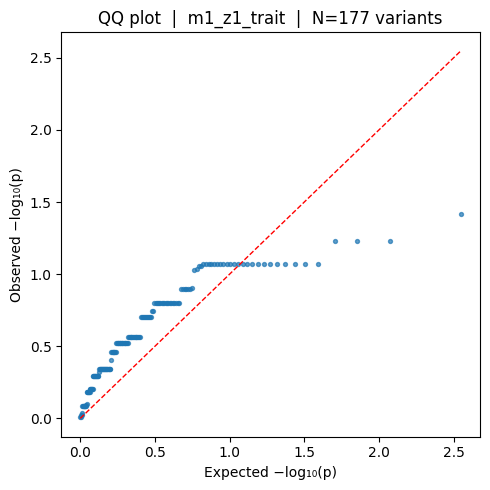

In [26]:
# ── Step 8: Load, filter, and visualise GWAS results ─────────────────────────
import numpy as np

# Load the linear regression results produced by plink2.
# Columns: #CHROM POS ID REF ALT A1 A1_FREQ TEST OBS_CT BETA SE T_STAT P ERRCODE
res = pd.read_csv(
    f"{VCF_FOLDER}/{RESULTS_FILE}.{TRAIT}.glm.linear", sep="\t"
)
print(f"Total variants tested: {len(res)}")

# ── 8a. Filter to testable variants ───────────────────────────────────────────
# Keep only variants where:
#   - A1_FREQ is between 0.10 and 0.90 (MAF > 10%)
#     Very rare variants are unreliable with small N: a single carrier
#     dominates the regression and inflates the effect size.
#   - P is not NaN: NaN means the variant is monomorphic or perfectly collinear
#     with a covariate (plink reports ERRCODE = CONST_OMITTED_ALLELE).
testable = res[
    (res["A1_FREQ"] > 0.10) & (res["A1_FREQ"] < 0.90) & res["P"].notna()
].copy()
print(f"Testable variants (MAF > 10%, non-NaN p): {len(testable)}")

# ── 8b. Top associations ──────────────────────────────────────────────────────
# Multiple variants with identical BETA/SE/P → perfect LD (same haplotype).
# They represent the same signal; the first hit summarises it.
print("\nTop 10 associations:")
display(
    testable.sort_values("P").head(10)
              #[["#CHROM", "POS", "ID", "A1", "A1_FREQ", "OBS_CT", "BETA", "SE", "P"]]
)

# ── 8c. QQ plot ───────────────────────────────────────────────────────────────
# Compares observed −log10(p) distribution vs the expected null (uniform).
# Interpretation:
#   - Bulk of points on the red diagonal → well-calibrated (no inflation)
#   - Only the top few points above the line → plausible true signal
p_vals   = testable["P"].sort_values().values
n        = len(p_vals)
expected = -np.log10((np.arange(1, n + 1) - 0.5) / n)  # theoretical uniform quantiles
observed = -np.log10(p_vals)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(expected, observed, s=8, alpha=0.7)
ax.plot([0, expected.max()], [0, expected.max()], "r--", lw=1)  # null diagonal
ax.set_xlabel("Expected −log₁₀(p)")
ax.set_ylabel("Observed −log₁₀(p)")
ax.set_title(f"QQ plot  |  {TRAIT}  |  N={n} variants")
plt.tight_layout(); plt.show()

SNP column: 5:80751257:A:C_A  →  counting copies of 'A' allele

13 donors after merge
original_donor_id genotype  dosage  m1_z1_trait
       SCF-18-004       CC       0    -0.946457
       SCF-20-025       AC       1    -0.106301
       SCF-21-030       CC       0     0.026528
       SCF-18-003       CC       0    -0.946457
       SCF-20-023       AA       2     0.106301
       SCF-19-009       AA       2    -0.053075
       SCF_20-024       AC       1    -0.380326
       SCF_22-043       AA       2    -0.268441
       SCF-19-018       AC       1    -0.946457
       SCF-19-014       AC       1     0.213819
       SCF-18-006       CC       0    -0.946457
      PCMC-16-012       CC       0    -0.946457
       SCF-22-045       AC       1    -0.946457


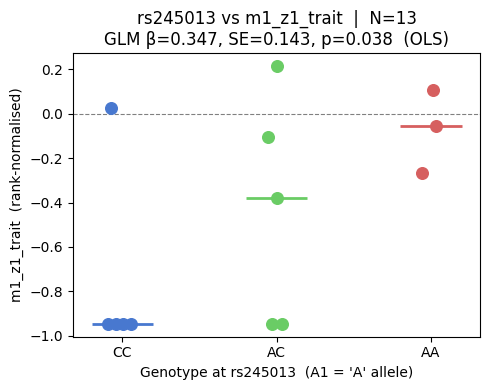


Spearman  ρ = +0.530   p = 0.0624
  → positive association: more 'A' alleles = higher m1_z1_trait



Permutation  p = 0.0632  (|ρ| ≥ 0.530 in 100,000 shuffles)

── Summary ─────────────────────────────────────────────────────────
  OLS β = 0.347  95% CI [0.067, 0.627]
  Meaning: each extra 'A' allele shifts m1_z1_trait by +0.347 SD
  OLS p = 0.038  |  Spearman p = 0.0624  |  Permutation p = 0.0632
  All 3 tests agree directionally. Pre-specified hypothesis → no correction needed.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Load genotype dosage file exported by plink2 ──────────────────────────────
# .raw file: one row per donor, one column per variant
# dosage = number of A1 alleles (0, 1, or 2)
geno = pd.read_csv(f"{VCF_FOLDER}/subset/plink/geno_dosage.raw", sep="\t")

# Find the column for our SNP by position
snp_col = [c for c in geno.columns if ":80751257:" in c][0]
a1 = snp_col.split("_")[-1]   # A1 allele whose copies are counted (here: A)
print(f"SNP column: {snp_col}  →  counting copies of '{a1}' allele")

# Keep only IID and dosage, rename to match df_meta_diseased
geno = (geno[["IID", snp_col]]
        .rename(columns={"IID": "original_donor_id", snp_col: "dosage"}))
geno["dosage"] = geno["dosage"].astype(int)

# ── Merge genotype with trait ──────────────────────────────────────────────────
# df_meta_diseased has one row per XDP donor with the computed trait
df = df_meta_diseased.merge(geno, on="original_donor_id", how="inner")
print(f"\n{len(df)} donors after merge")

# Human-readable genotype label (e.g. dosage 1 → "AC")
other = "C" if a1 == "A" else "A"
label_map = {0: f"{other}{other}", 1: f"{a1}{other}", 2: f"{a1}{a1}"}
df["genotype"] = df["dosage"].map(label_map)
print(df[["original_donor_id", "genotype", "dosage", "m1_z1_trait"]].to_string(index=False))

# ── Plot: every donor visible (N=13 is too small to hide in a boxplot) ─────────
# Strip plot shows all points; median line per group added manually
fig, ax = plt.subplots(figsize=(5, 4))
groups = sorted(df["dosage"].unique())
palette = {0: "#4878CF", 1: "#6ACC65", 2: "#D65F5F"}

for g in groups:
    sub = df[df["dosage"] == g]["m1_z1_trait"]
    x = g + np.random.uniform(-0.1, 0.1, size=len(sub))  # jitter
    ax.scatter(x, sub, color=palette[g], s=70, zorder=3, label=label_map[g])
    ax.hlines(sub.median(), g - 0.2, g + 0.2, color=palette[g], linewidth=2, zorder=4)

ax.set_xticks(groups)
ax.set_xticklabels([label_map[g] for g in groups])
ax.set_xlabel(f"Genotype at rs245013  (A1 = '{a1}' allele)")
ax.set_ylabel("m1_z1_trait  (rank-normalised)")
ax.set_title(f"rs245013 vs m1_z1_trait  |  N={len(df)}\n"
             f"GLM β={0.347:.3f}, SE={0.143:.3f}, p=0.038  (OLS)")
# horizontal line at 0 = population median of the RINT trait
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.tight_layout(); plt.show()

# ── Spearman correlation ───────────────────────────────────────────────────────
# Spearman is safer than OLS at N=13: no normality assumption needed.
# We treat dosage as an ordinal score (0 < 1 < 2 copies of the A allele).
rho, p_spear = stats.spearmanr(df["dosage"], df["m1_z1_trait"])
print(f"\nSpearman  ρ = {rho:+.3f}   p = {p_spear:.4f}")
print(f"  → {'positive' if rho > 0 else 'negative'} association: "
      f"more '{a1}' alleles = {'higher' if rho > 0 else 'lower'} m1_z1_trait")

# ── Permutation p-value ────────────────────────────────────────────────────────
# At N=13 the OLS p-value relies on a large-sample approximation that may be wrong.
# Permutation gives an exact p-value: we randomly shuffle the trait 100,000 times
# and ask: how often does a random shuffle produce a |ρ| as large as what we observed?
np.random.seed(42)
n_perm = 100_000
obs = abs(rho)
null_rhos = [
    abs(stats.spearmanr(np.random.permutation(df["dosage"]), df["m1_z1_trait"])[0])
    for _ in range(n_perm)
]
p_perm = np.mean(np.array(null_rhos) >= obs)
print(f"\nPermutation  p = {p_perm:.4f}  (|ρ| ≥ {obs:.3f} in {n_perm:,} shuffles)")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n── Summary ─────────────────────────────────────────────────────────")
print(f"  OLS β = 0.347  95% CI [{0.347-1.96*0.143:.3f}, {0.347+1.96*0.143:.3f}]")
print(f"  Meaning: each extra '{a1}' allele shifts m1_z1_trait by +0.347 SD")
print(f"  OLS p = 0.038  |  Spearman p = {p_spear:.4f}  |  Permutation p = {p_perm:.4f}")
print(f"  All 3 tests agree directionally. Pre-specified hypothesis → no correction needed.")


A) Genotype (dosage) vs clinical variables
   Spearman ρ between A-allele count and each variable
  age_of_onset          N=13  ρ=+0.382  p=0.1978  
  age_of_death          N=13  ρ=+0.077  p=0.8033  
  disease_duration      N=13  ρ=-0.599  p=0.0304  *
  repeat_length         N=13  ρ=-0.026  p=0.9317  

B) Trait (m1_z1_trait) vs clinical variables
   Spearman ρ between trait and each variable
  age_of_onset          N=13  ρ=-0.120  p=0.6956  
  age_of_death          N=13  ρ=-0.131  p=0.6698  
  disease_duration      N=13  ρ=-0.518  p=0.0698  ~
  repeat_length         N=13  ρ=+0.423  p=0.1498  


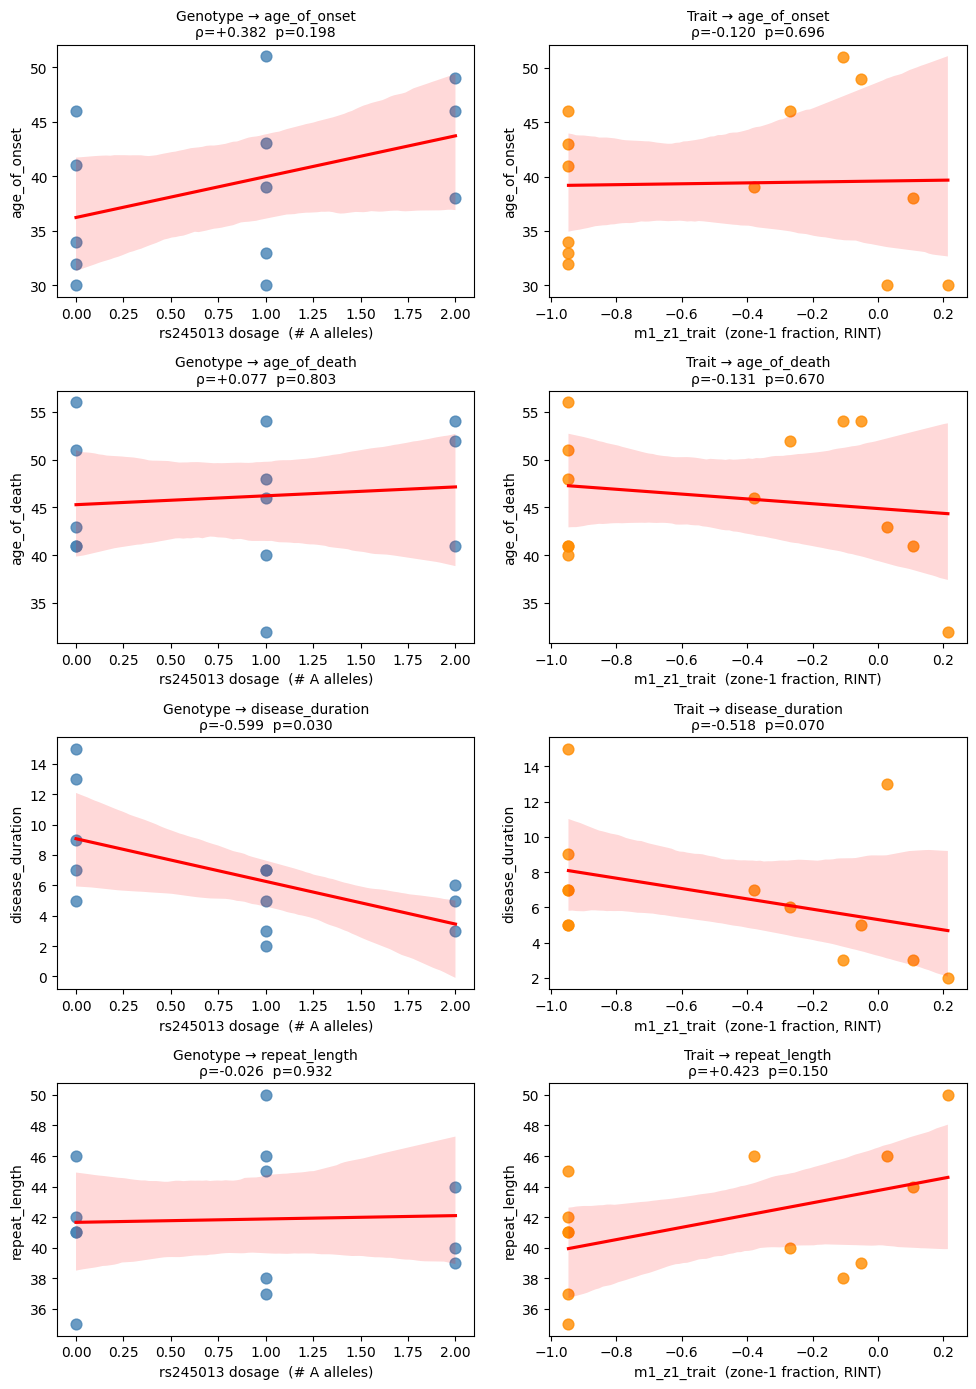

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Clinical variables to test ────────────────────────────────────────────────
# Convert to numeric (some entries may be strings like "not_applicable")
clinical_vars = ["age_of_onset", "age_of_death", "disease_duration", "repeat_length"]

df_clin = df.copy()   # df already has dosage + trait merged
for v in clinical_vars:
    df_clin[v] = pd.to_numeric(df_clin[v], errors="coerce")

# ── Part A: Is the GENOTYPE associated with clinical variables? ───────────────
# i.e. do A-allele carriers have later onset / longer survival?
print("=" * 55)
print("A) Genotype (dosage) vs clinical variables")
print("   Spearman ρ between A-allele count and each variable")
print("=" * 55)

results_geno = []
for v in clinical_vars:
    sub = df_clin[["dosage", v]].dropna()
    if len(sub) < 5:
        print(f"  {v}: too few values ({len(sub)}), skip")
        continue
    rho, p = stats.spearmanr(sub["dosage"], sub[v])
    results_geno.append({"variable": v, "N": len(sub), "rho": rho, "p": p})
    sig = "*" if p < 0.05 else ("~" if p < 0.10 else "")
    print(f"  {v:<20}  N={len(sub)}  ρ={rho:+.3f}  p={p:.4f}  {sig}")

# ── Part B: Is the TRAIT associated with clinical variables? ──────────────────
# i.e. do donors with more zone-1 cells have later onset / longer survival?
print()
print("=" * 55)
print("B) Trait (m1_z1_trait) vs clinical variables")
print("   Spearman ρ between trait and each variable")
print("=" * 55)

results_trait = []
for v in clinical_vars:
    sub = df_clin[["m1_z1_trait", v]].dropna()
    if len(sub) < 5:
        continue
    rho, p = stats.spearmanr(sub["m1_z1_trait"], sub[v])
    results_trait.append({"variable": v, "N": len(sub), "rho": rho, "p": p})
    sig = "*" if p < 0.05 else ("~" if p < 0.10 else "")
    print(f"  {v:<20}  N={len(sub)}  ρ={rho:+.3f}  p={p:.4f}  {sig}")

# ── Scatter plots: one row per variable, genotype left / trait right ──────────
fig, axes = plt.subplots(len(clinical_vars), 2,
                         figsize=(10, 3.5 * len(clinical_vars)))

for i, v in enumerate(clinical_vars):
    sub = df_clin[["dosage", "m1_z1_trait", v]].dropna()

    # Left: genotype vs clinical
    ax = axes[i, 0]
    sns.regplot(data=sub, x="dosage", y=v, ax=ax,
                scatter_kws={"s": 60, "color": "steelblue"},
                line_kws={"color": "red"})
    rho_g = next((r["rho"] for r in results_geno if r["variable"] == v), np.nan)
    p_g   = next((r["p"]   for r in results_geno if r["variable"] == v), np.nan)
    ax.set_xlabel("rs245013 dosage  (# A alleles)")
    ax.set_ylabel(v)
    ax.set_title(f"Genotype → {v}\nρ={rho_g:+.3f}  p={p_g:.3f}", fontsize=10)

    # Right: trait vs clinical
    ax2 = axes[i, 1]
    sns.regplot(data=sub, x="m1_z1_trait", y=v, ax=ax2,
                scatter_kws={"s": 60, "color": "darkorange"},
                line_kws={"color": "red"})
    rho_t = next((r["rho"] for r in results_trait if r["variable"] == v), np.nan)
    p_t   = next((r["p"]   for r in results_trait if r["variable"] == v), np.nan)
    ax2.set_xlabel("m1_z1_trait  (zone-1 fraction, RINT)")
    ax2.set_ylabel(v)
    ax2.set_title(f"Trait → {v}\nρ={rho_t:+.3f}  p={p_t:.3f}", fontsize=10)

plt.tight_layout()
plt.show()


In [29]:
import igv_notebook
igv_notebook.init()
b = igv_notebook.Browser({
    "genome": "hg38",
    "locus": "chrX:71,366,131-71,532,374",
    "tracks": [{
        "name": "TAF1",
        "path": "/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam",
        "indexPath": "/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam.bai",
        "format": "bam",
        "type": "alignment"
    }]
})

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
import requests

def get_rsid(chrom, pos, ref, alt):
    # Format the query as HGVS (e.g., chr5:g.77178682G>A)
    hgvs = f"chr{chrom}:g.{pos}{ref}>{alt}"
    
    # Query MyVariant.info API (defaults to hg38; use assembly=hg19 parameter if needed)
    url = f"https://myvariant.info/v1/variant/{hgvs}?fields=dbsnp.rsid"
    
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        # Navigate the JSON to extract the rsID
        return data.get("dbsnp", {}).get("rsid", "No rsID found")
    else:
        return "Variant not found or query failed"

# Test your specific variant
rs_name = get_rsid(5, 77178682, 'G', 'A')
print(f"The rsID is: {rs_name}")

The rsID is: Variant not found or query failed
